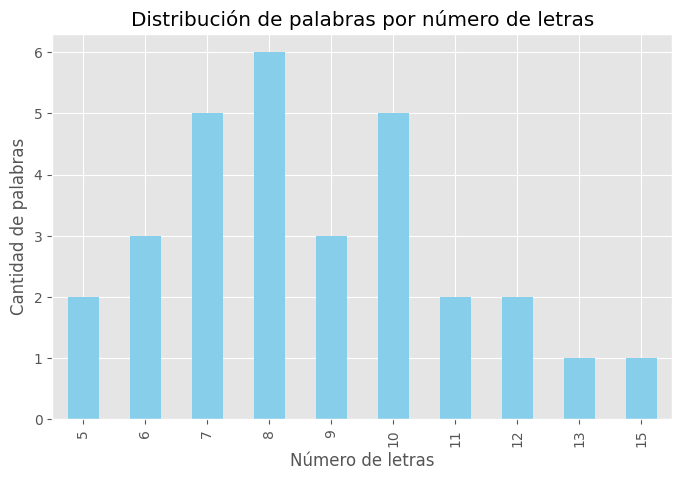

Usuarios únicos: 2

Top 5 usuarios con más rondas ganadas:
username
Adrian    6
Hugo      4
Name: count, dtype: int64

Top 5 usuarios con mayor puntuación acumulada:
username
Adrian    6
Hugo      4
Name: final_score, dtype: int64

Top 5 usuarios con mayor media de puntuación:
username
Adrian    2.0
Hugo      2.0
Name: final_score, dtype: float64


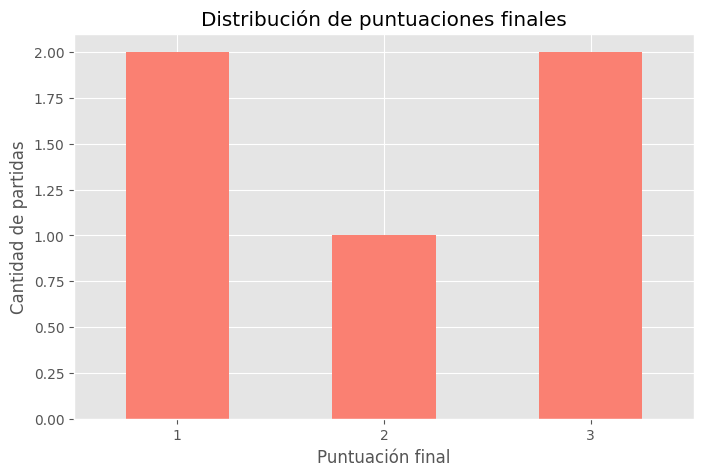


Distribución de puntuaciones finales:
1 puntos: 2 partidas
2 puntos: 1 partidas
3 puntos: 2 partidas


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot') 

# Words.csv
words_df = pd.read_csv("words.csv", header=None, names=["word"])
words_df["length"] = words_df["word"].apply(len)
length_counts = words_df["length"].value_counts().sort_index()

length_counts.plot(kind="bar", figsize=(8,5), color="skyblue")
plt.title("Distribución de palabras por número de letras")
plt.xlabel("Número de letras")
plt.ylabel("Cantidad de palabras")
plt.show()

# Rounds_in_games.csv
rounds_df = pd.read_csv(
    "rounds_in_games.csv",
    header=None,
    names=["game_id", "word", "username", "round_id", "user_trys", "victory"]
)

# Convertimos victory a booleano
rounds_df["victory"] = rounds_df["victory"].astype(bool)

# Total de usuarios únicos
total_users = rounds_df["username"].nunique()
print(f"Usuarios únicos: {total_users}")

# Top 5 usuarios con más rondas ganadas
top_winners = rounds_df[rounds_df["victory"] == True]["username"].value_counts().head(5)
print("\nTop 5 usuarios con más rondas ganadas:")
print(top_winners)


# Games.csv
games_df = pd.read_csv(
    "games.csv",
    header=None,
    names=["game_id", "username", "start_date", "end_date", "final_score"]
)

# Top 5 usuarios con mayor puntuación acumulada
top_total_score = games_df.groupby("username")["final_score"].sum().sort_values(ascending=False).head(5)
print("\nTop 5 usuarios con mayor puntuación acumulada:")
print(top_total_score)

# Top 5 usuarios con mayor media de puntuación
top_mean_score = games_df.groupby("username")["final_score"].mean().sort_values(ascending=False).head(5)
print("\nTop 5 usuarios con mayor media de puntuación:")
print(top_mean_score)


# Histograma de puntuaciones finales
score_counts = games_df["final_score"].value_counts().sort_index()

score_counts.plot(kind="bar", figsize=(8,5), color="salmon")
plt.title("Distribución de puntuaciones finales")
plt.xlabel("Puntuación final")
plt.ylabel("Cantidad de partidas")
plt.xticks(rotation=0)
plt.show()

# Imprimir la distribución en texto
print("\nDistribución de puntuaciones finales:")
for score, count in score_counts.items():
    print(f"{score} puntos: {count} partidas")